/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=20. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/xgboost/core.py:729: UserWarning: [10:08:14] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/xgboost/core.py:729: UserWarning: [10:08:14] WARNING: /workspace/src/common/error_msg.cc:58: Falling back 

{'subsample': 0.8, 'reg_lambda': 25, 'reg_alpha': 0.08, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
              precision    recall  f1-score   support

       early       0.73      0.75      0.74        40
        late       0.68      0.89      0.77       121
      middle       0.45      0.16      0.23        58

    accuracy                           0.67       219
   macro avg       0.62      0.60      0.58       219
weighted avg       0.63      0.67      0.62       219



/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/xgboost/core.py:729: UserWarning: [10:08:37] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


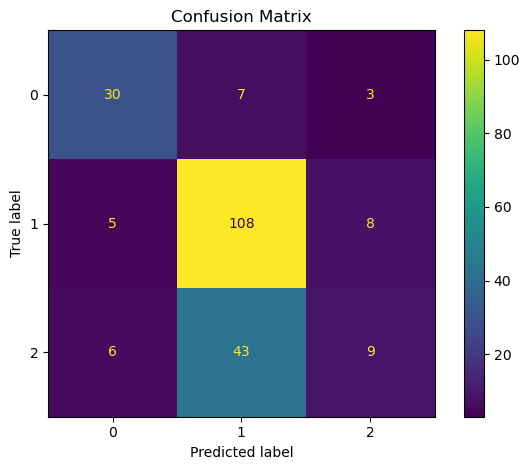

weight:  {'f0': 3.0, 'f1': 2.0, 'f4': 2.0, 'f5': 2.0, 'f6': 2.0, 'f7': 3.0, 'f8': 4.0, 'f9': 4.0, 'f10': 5.0, 'f11': 3.0, 'f12': 6.0, 'f13': 3.0, 'f14': 2.0, 'f15': 3.0, 'f16': 1.0, 'f17': 23.0, 'f18': 5.0, 'f19': 3.0, 'f20': 25.0, 'f21': 26.0, 'f22': 2.0, 'f23': 5.0, 'f24': 1.0, 'f25': 2.0, 'f26': 39.0, 'f27': 8.0, 'f28': 7.0, 'f30': 6.0, 'f31': 3.0, 'f32': 4.0, 'f33': 3.0, 'f34': 24.0, 'f35': 10.0, 'f36': 1.0, 'f37': 7.0, 'f38': 5.0, 'f39': 3.0, 'f40': 2.0, 'f41': 5.0, 'f42': 33.0, 'f43': 9.0, 'f44': 7.0, 'f45': 7.0, 'f46': 3.0, 'f47': 4.0, 'f48': 5.0, 'f49': 3.0, 'f51': 4.0, 'f52': 10.0, 'f53': 1.0, 'f54': 27.0, 'f55': 4.0, 'f56': 5.0, 'f57': 3.0, 'f58': 1.0, 'f59': 18.0, 'f60': 3.0, 'f61': 5.0, 'f63': 19.0, 'f65': 6.0, 'f66': 5.0, 'f67': 15.0, 'f68': 2.0, 'f69': 3.0, 'f70': 23.0, 'f71': 3.0, 'f72': 48.0, 'f73': 17.0, 'f74': 8.0, 'f75': 4.0, 'f76': 12.0, 'f78': 8.0, 'f79': 14.0, 'f80': 15.0, 'f81': 5.0, 'f83': 2.0, 'f84': 2.0, 'f85': 1.0, 'f86': 1.0, 'f87': 3.0, 'f89': 9.0, 'f90': 5

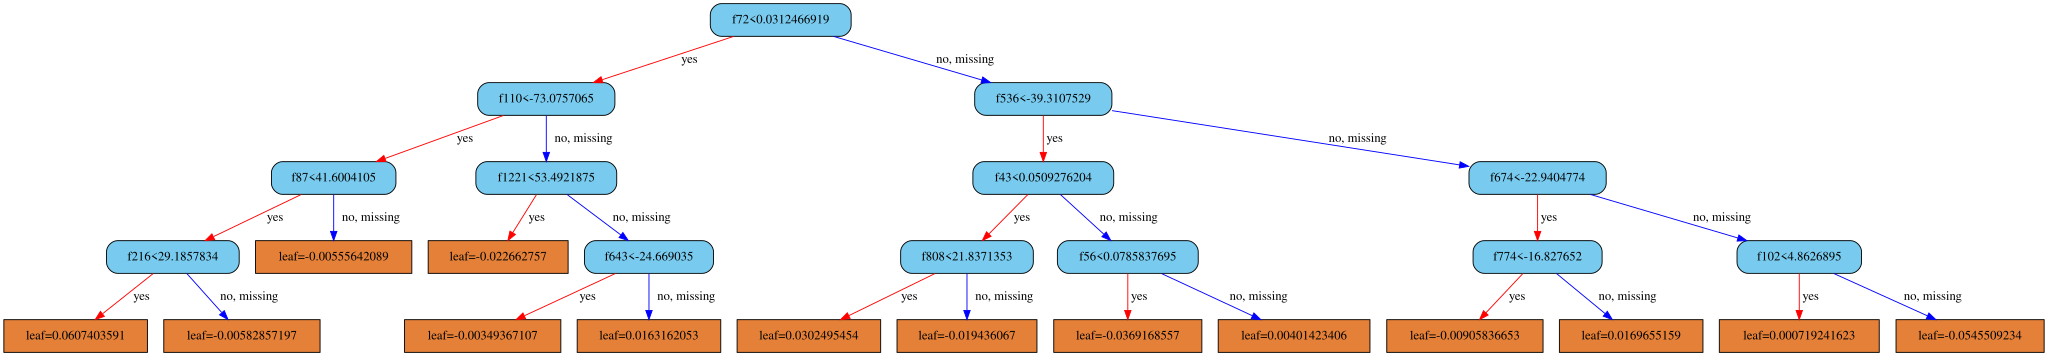

In [ ]:
import pickle
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier, plot_tree, to_graphviz
import pandas as pd
import matplotlib.pyplot as plt
import cupy as cp
from sklearn.utils.class_weight import compute_sample_weight
import time

# import training and test data
data = open("data/splits_full.pkl", "rb")
[X_train, X_test, y_train, y_test] = pickle.load(data)
data.close()

## Train model

start_time = time.time()

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

param_grid = {
    "max_depth": [4],
    "learning_rate": [0.1, 0.15, 0.2],
    "gamma": [0.1],
    "reg_lambda": [25],
    "reg_alpha": [0.08],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}
# Round 1
# {
#     "subsample": 1.0,
#     "reg_lambda": 20,
#     "reg_alpha": 5,
#     "max_depth": 6,
#     "learning_rate": 0.1,
#     "gamma": 0.1,
#     "colsample_bytree": 0.7,
# }
# early 0.65
# late  0.77
# mid   0.27
# acc   0.65
#
# ->
#
# Round 2
# {
#     "subsample": 1.0,
#     "reg_lambda": 30,
#     "reg_alpha": 0.1,
#     "max_depth": 4,
#     "learning_rate": 0.3,
#     "gamma": 0.1,
#     "colsample_bytree": 1.0,
# }
# early 0.72
# late  0.76
# mid   0.31
# acc   0.66
#
# ->
#
# {
#     "subsample": 0.8,
#     "reg_lambda": 30,
#     "reg_alpha": 0.1,
#     "max_depth": 3,
#     "learning_rate": 0.1,
#     "gamma": 0.1,
#     "colsample_bytree": 1.0,
# }
# early 0.73
# late  0.78
# mid   0.28
# acc   0.67
# ->
# {'subsample': 0.8, 'reg_lambda': 25, 'reg_alpha': 0.08, 'max_depth': 4, 'learning_rate': 0.15, 'gamma': 0.1, 'colsample_bytree': 0.8}
# early 0.74
# late  0.77
# mid   0.23
# acc   0.67

optimal_params = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        seed=42,
        subsample=0.9,
        colsample_bytree=0.5,
        device="cuda",
    ),
    param_distributions=param_grid,
    scoring="roc_auc_ovr",
    n_iter=20,
    cv=5,
    n_jobs=10,
    random_state=42,
)

## Evaluate model
optimal_params.fit(X_train, y_train)  # , sample_weight=sample_weights)

print(optimal_params.best_params_)

end_time = time.time()
elapsed_time = end_time - start_time

optimized = optimal_params.best_estimator_
y_pred = optimized.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["early", "late", "middle"]))
ConfusionMatrixDisplay.from_estimator(optimized, X_test, y_test)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

bt = optimized.get_booster()
for importance_type in ("weight", "total_gain", "total_cover", "gain", "cover"):
    print("%s: " % importance_type, bt.get_score(importance_type=importance_type))

node_params = {"shape": "box", "style": "filled, rounded", "fillcolor": "#78cbef"}
leaf_params = {"shape": "box", "style": "filled", "fillcolor": "#e48038"}

to_graphviz(
    optimized,
    tree_idx=0,
    size="10,10",
    condition_node_params=node_params,
    leaf_node_params=leaf_params,
)


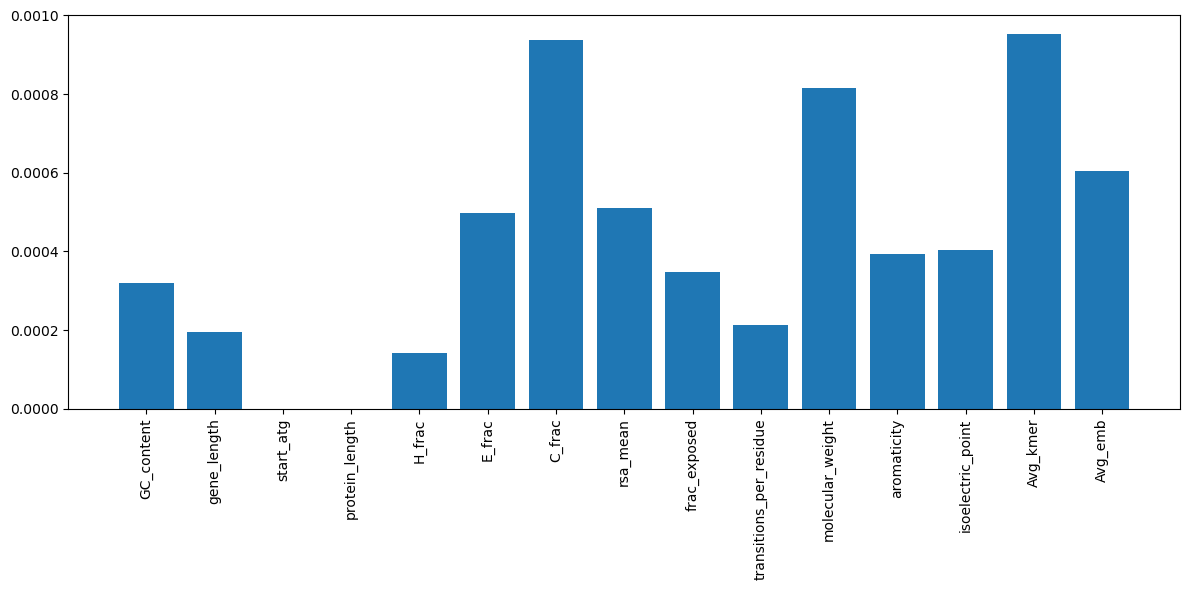

In [ ]:
# Plot feature importance
import numpy as np

simple_features = [
    "GC_content",
    "gene_length",
    "start_atg",
    "protein_length",
    "H_frac",
    "E_frac",
    "C_frac",
    "rsa_mean",
    "frac_exposed",
    "transitions_per_residue",
    "molecular_weight",
    "aromaticity",
    "isoelectric_point",
]  # Simple features

# feature_names = simple_features + [str(i) for i in range(13, 83)]  # with Kmers
feature_names = simple_features + [str(i) for i in range(13, 1619)]  # with embeddings

importances = optimized.feature_importances_

avg_kmer_importance = np.mean(importances[13:83])
avg_emb_importance = np.mean(importances[83:1619])

combined_importances = list(importances[:13]) + [
    avg_kmer_importance,
    avg_emb_importance,
]

importance_labels = simple_features + ["Avg_kmer", "Avg_emb"]

plt.figure(figsize=(12, 6))
plt.bar(range(len(combined_importances)), combined_importances)
plt.xticks(range(len(combined_importances)), importance_labels, rotation=90)
plt.tight_layout()
plt.show()